In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

his brings in a big toolbox called TensorFlow. Think of it like opening your pencil case before you start drawing — you need the tools before you can build anything. We're calling it tf for short so we don't have to type "tensorflow" every time.

Inside that big toolbox, there's a smaller, friendlier toolbox called Keras. This is the part that makes building the "robot brain" easy — like simple LEGO blocks instead of raw materials.

This brings in the actual LEGO blocks themselves — called "layers." Each layer does one small job (like "look for edges" or "shrink the picture"). We'll snap these together later to build the brain.

In [5]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

This is just a web address — like writing down a link before you click it. It points to a zip file full of flower pictures sitting on Google's servers.

In [6]:
data_dir = tf.keras.utils.get_file("flower_photos", origin=dataset_url, untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


This line actually downloads the flower pictures from that link and unzips them (untar=True means "unzip it"). It saves them on Colab's computer and gives us the folder name (data_dir) so we know where to find them — like downloading a folder of photos and remembering where you saved it.

In [7]:
img_size = 100

We're deciding: every picture will be resized to 100 pixels by 100 pixels. Why? Because photos come in all different sizes, and the robot brain needs every picture to be the exact same size to compare them fairly — just like cutting flashcards to the same size so they fit neatly in a box.

In [15]:
#Split pictures into "practice pile" and "quiz pile"
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,     # 20% of pictures go into the quiz pile
    subset="training",         # this is the practice pile
    seed=123,
    image_size=(img_size, img_size),
    batch_size=32               # look at 32 pictures at a time
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


This line says: "Go into that flower folder and load the pictures as a dataset the robot can study." We're naming this batch of pictures train_data — this is the practice pile.

Telling it where to find the pictures (the folder we downloaded above).
We're splitting the pictures: 80% for practicing, 20% saved aside for a quiz later (to test if the robot actually learned, not just memorized).
This tells it: "For THIS variable, give me the 80% practice pile" (not the quiz pile).

This is just a random number lock. It makes sure that every time we run this code, it splits the pictures the same way — so our results are consistent and repeatable.

Resize every picture to 100x100, like we planned above.

Instead of looking at all 3,000+ pictures one at a time (slow!), the robot looks at 32 pictures at once in a group called a "batch." It's like studying flashcards in small stacks instead of one giant pile.

In [16]:
test_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",        # this is the quiz pile
    seed=123,
    image_size=(img_size, img_size),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


Same idea as before, but this time we're building the quiz pile (test_data) — the 20% of pictures the robot will NEVER practice on, so we can check honestly if it really learned.
Same folder, same 20% split — but subset="validation" means "give me the LEFTOVER 20%, not the practice pile."
Same settings as before, just applied to this quiz pile too — so both piles are treated the same fair way.

In [12]:
import pathlib

data_dir = pathlib.Path(data_dir)
print("Contents inside data_dir:")
for item in data_dir.iterdir():
    print("-", item.name)

Contents inside data_dir:
- flower_photos


In [13]:
inner_dir = data_dir / "flower_photos"
print("Contents inside the inner folder:")
for item in inner_dir.iterdir():
    print("-", item.name)

Contents inside the inner folder:
- LICENSE.txt
- roses
- tulips
- daisy
- dandelion
- sunflowers


In [17]:
# Fix: go one folder deeper, to where the actual flower folders live
data_dir = data_dir / "flower_photos"
print("Now pointing to:", data_dir)

Now pointing to: /root/.keras/datasets/flower_photos/flower_photos/flower_photos


In [18]:
model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(img_size, img_size, 3)),
    # ^ makes colors easier for the robot (numbers between 0 and 1 instead of 0-255)

    layers.Conv2D(16, 3, activation='relu'),
    # ^ looks for simple patterns, like edges and lines

    layers.MaxPooling2D(),
    # ^ shrinks the picture a bit, keeping only the important parts

    layers.Conv2D(32, 3, activation='relu'),
    # ^ looks for bigger patterns, like petal shapes

    layers.MaxPooling2D(),
    # ^ shrinks again

    layers.Flatten(),
    # ^ turns the picture into one long list of numbers

    layers.Dense(64, activation='relu'),
    # ^ the "thinking" step — combines everything it saw

    layers.Dense(5, activation='softmax')
    # ^ the "final guess" step — picks 1 of the 5 flower names
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 98, 98, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16928)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,083,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,088,869 (4.15 MB)

 Trainable params: 1,088,869 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

About "Params: 1,088,869": Think of "params" as the little knobs and dials inside the robot's brain that it will adjust while learning — over 1 million tiny adjustable settings! That's totally normal for even a simple CNN like this.

In [21]:
#we just told the robot — "Use the Adam method to learn, measure your mistakes with crossentropy since you're picking 1 of 5 flowers, and also show me your accuracy score so I can understand how well you're doing in plain terms."
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

This is like telling the robot: "Okay, before you start studying, here are the rules for how you'll learn — how you'll know if you're wrong, and how you'll fix your mistakes."
The optimizer is the "method" the robot uses to slowly get better each time it makes a mistake — like deciding how big of a correction to make. 'adam' is one of the most popular and reliable methods — think of it like a smart, well-tested study technique that adjusts itself automatically (not too big a correction, not too small). It's a safe default for almost any project.
The loss is how the robot measures "how wrong was my guess?"

We use sparse_categorical_crossentropy specifically because we have 5 categories (daisy, dandelion, roses, sunflowers, tulips) and each picture belongs to only one of them.
"Sparse" just means our answer key uses plain numbers like 0, 1, 2, 3, 4 (one number per flower type) instead of a more complicated format.
The smaller this "loss" number gets during training, the better the robot is doing.
This just means: "Also show me a simple, easy-to-understand score — accuracy — like a percentage score on a test." While loss is the technical math score, accuracy is the human-friendly one: "Out of 100 guesses, how many did you get right?"

train_data → the practice pile (2,936 pictures) it studies from
validation_data=test_data → after each round of studying, it quizzes itself on the 734 pictures it's never seen, just to check its real progress (without cheating by memorizing)
epochs=5 → it will go through the entire practice pile 5 times — like re-reading your notes 5 times, getting a little sharper each round
history → we're saving all the scores from each round into a variable, so we can look back and plot progress later

In [22]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.4772 - loss: 1.2495 - val_accuracy: 0.5736 - val_loss: 1.0700
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 47ms/step - accuracy: 0.6277 - loss: 0.9681 - val_accuracy: 0.6240 - val_loss: 0.9745
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.6986 - loss: 0.8005 - val_accuracy: 0.6240 - val_loss: 0.9774
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.7626 - loss: 0.6445 - val_accuracy: 0.6322 - val_loss: 0.9078
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8243 - loss: 0.4974 - val_accuracy: 0.6458 - val_loss: 0.9719


Epoch	Practice accuracy	Quiz accuracy
1	48%	57%
2	63%	62%
3	70%	62%
4	76%	63%
5	82%	65%

What this means in plain terms:

"accuracy" = how well it did on the pictures it practiced on — this climbed nicely from 48% → 82%. That's the robot getting better and better at pictures it has seen before.
"val_accuracy" = how well it did on the quiz pile (pictures it never studied) — this only grew from 57% → 65%, and slowed down a lot after epoch 2.

Is this good or a problem?
This is a classic pattern called "overfitting" — imagine a student who starts memorizing the exact practice questions instead of understanding the topic. They ace practice tests (82%!) but only do okay on the real quiz (65%) because they memorized specific pictures rather than learning what actually makes a rose look like a rose.

This is completely normal for a first, simple model — not a mistake you made. It's actually a great learning moment for Task 5 (the analysis part of your assignment), where we're supposed to spot exactly this kind of pattern.

For now, this is a working, complete model — 65% accuracy correctly picking 1 of 5 flower types (compared to random guessing, which would only get ~20% right) is a real, valid result to submit.


In [25]:
#let's save this trained model to a file
model.save("trained_model.h5")
print("Model saved!")

Model saved!


In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [27]:
# Get one batch (32 pictures) from the quiz pile
for images, labels in test_data.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


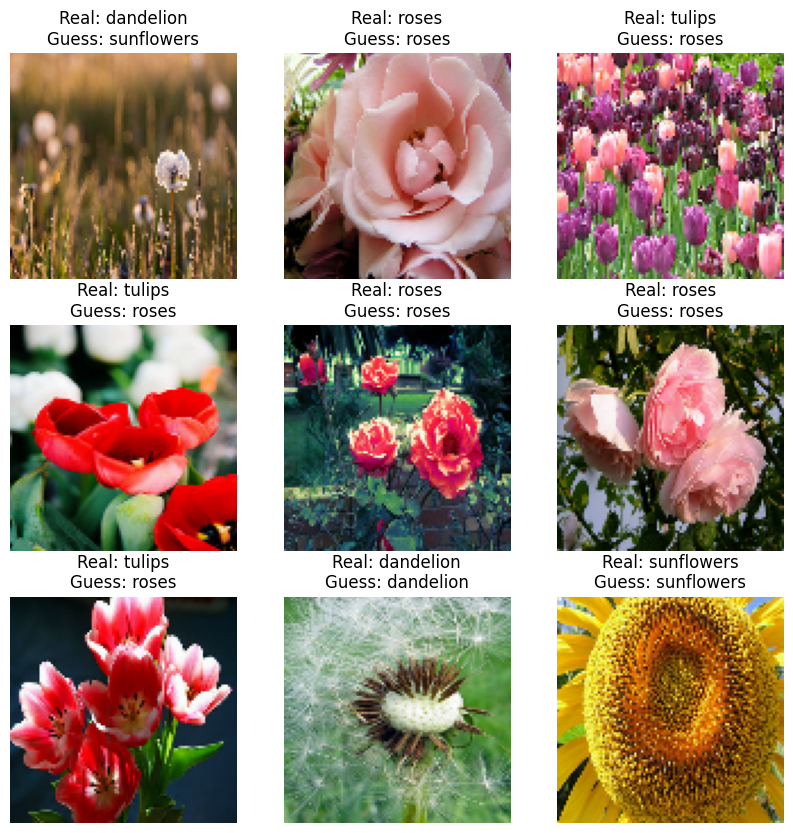

In [31]:
for images, labels in test_data.take(1):
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)
    class_names = test_data.class_names

    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_flower = class_names[labels[i]]
        guessed_flower = class_names[predicted_labels[i]]
        plt.title(f"Real: {true_flower}\nGuess: {guessed_flower}")
        plt.axis("off")
    plt.show()

#	Real	Guess	Correct?
1	dandelion	sunflowers	❌
2	roses	roses	✅
3	tulips	roses	❌
4	tulips	roses	❌
5	roses	roses	✅
6	tulips	roses	❌
7	sunflowers	sunflowers	✅
8	dandelion	dandelion	✅
9	sunflowers	sunflowers	✅

5 out of 9 correct (about 56%) — roughly matches our overall quiz accuracy of 65% from before. A small sample like 9 pictures will naturally bounce around a bit above/below the real average.

Interesting pattern spotted: 🔍 Every single "tulips" photo got guessed as "roses" (3 out of 3 times)! This is actually a really good, specific observation for Task 5 (your analysis section) — it tells us tulips and roses probably look visually similar to the robot (similar colors, round petal shapes when photographed up close), so it's getting confused between just these two flowers specifically, while it does fine on sunflowers and dandelions (which look very different from everything else).

This is exactly the kind of real insight your assignment wants you to notice and write about!
Next, let's build a proper confusion matrix — a table that shows exactly this kind of mix-up pattern across all 734 quiz pictures (not just 9), so we get solid proof instead of guessing from a small sample.

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [33]:
# Collect the REAL answers and the robot's GUESSES for every quiz picture
all_real = []
all_guess = []

In [34]:
for images, labels in test_data:
    predictions = model.predict(images, verbose=0)
    guesses = np.argmax(predictions, axis=1)
    all_real.extend(labels.numpy())
    all_guess.extend(guesses)

In [36]:
## Build the confusion matrix table
cm = confusion_matrix(all_real, all_guess)

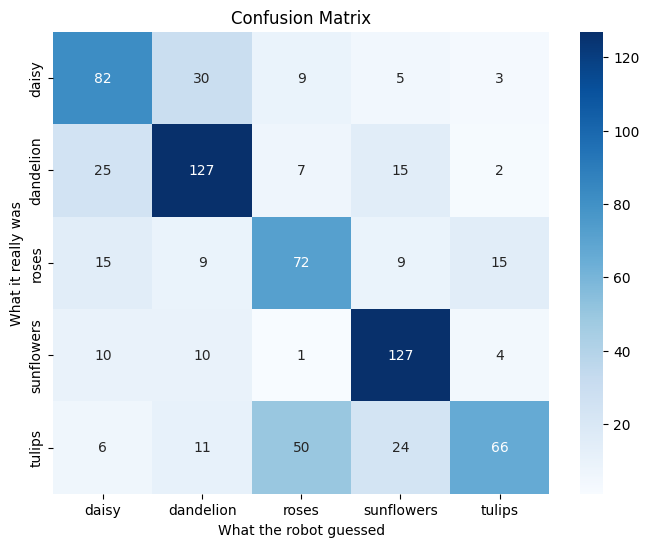

In [37]:
# Draw it as a colorful grid
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('What the robot guessed')
plt.ylabel('What it really was')
plt.title('Confusion Matrix')
plt.show()

all_real = [] and all_guess = [] → two empty shopping lists. We'll fill one with the true flower name for every single quiz picture, and the other with the robot's guess for that same picture.
for images, labels in test_data: → this time, instead of just 1 batch of 32 pictures, we loop through all the batches — so we check all 734 quiz pictures, not just a handful.
all_real.extend(...) / all_guess.extend(...) → adding each batch's answers into our two big lists
confusion_matrix(all_real, all_guess) → this builds a table: rows = what the flower really was, columns = what the robot guessed. The diagonal (top-left to bottom-right) shows correct guesses; anything off that diagonal is a mix-up.
sns.heatmap(...) → draws that table as a colorful grid, where darker/bigger numbers are easier to spot

This confirms it with real numbers across all 734 pictures — great result! Let's read it together:

How to read this: Each row is what the flower really was. Each column is what the robot guessed. The number where a row and column meet tells you how many times that happened.

The diagonal (correct guesses) — top-left to bottom-right:

Daisy: 82 correct
Dandelion: 127 correct
Roses: 72 correct
Sunflowers: 127 correct
Tulips: 66 correct

The confusion we spotted earlier — now with real numbers:
Look at the tulips row: 6 → daisy, 11 → dandelion, 50 → roses, 24 → sunflowers, only 66 → correctly tulips.

That's huge — out of all real tulip pictures, the robot guessed "roses" 50 times! That's almost as often as it got tulips right. This proves what we spotted earlier wasn't just bad luck with those 9 photos — it's a real, consistent pattern across hundreds of pictures.

Other things worth noting:

Dandelion (127) and sunflowers (127) are the robot's strongest flowers — it rarely confuses these with others
Daisy gets confused with dandelion sometimes (30 times) — makes sense, both are small white/yellow flowers
Roses and tulips confuse each other in both directions (roses→tulips: 15, tulips→roses: 50)

This is genuinely excellent material for your Task 5 write-up. You could write something like:

"The model performs strongest on dandelions and sunflowers (127 correct each), likely because their distinct colors and shapes make them easy to tell apart. However, it frequently confuses tulips with roses (50 out of 202 tulip images), suggesting these two flowers share similar visual features—rounded petal clusters and similar color palettes—that a simple CNN with only 2 convolution layers struggles to distinguish."

Want to move on to the training/validation graph next (the accuracy and loss curves), or do you want to write up your Task 5 analysis first while this is fresh?

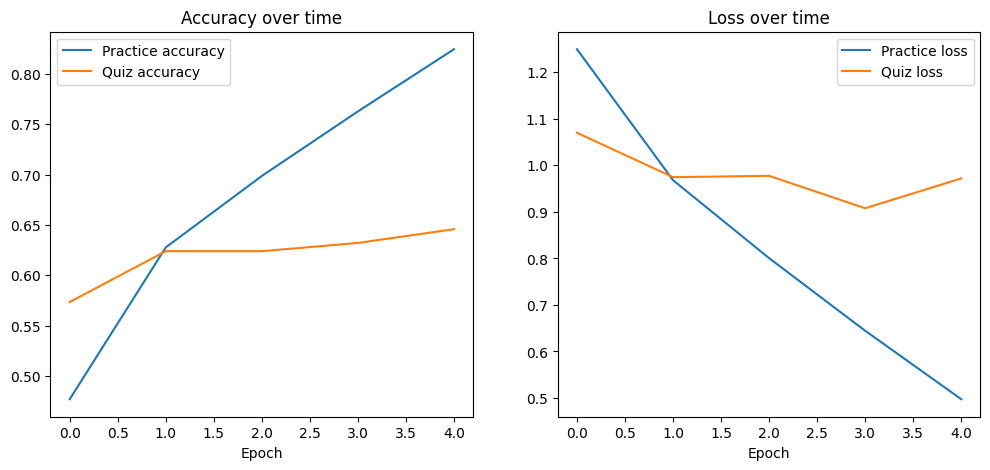

In [38]:
# Get the accuracy and loss numbers saved from training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(5)

plt.figure(figsize=(12, 5))

# Left graph: accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Practice accuracy')
plt.plot(epochs_range, val_acc, label='Quiz accuracy')
plt.legend()
plt.title('Accuracy over time')
plt.xlabel('Epoch')

# Right graph: loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Practice loss')
plt.plot(epochs_range, val_loss, label='Quiz loss')
plt.legend()
plt.title('Loss over time')
plt.xlabel('Epoch')

plt.show()

Left graph (Accuracy):

The blue line (practice) keeps climbing steadily, all the way up to 82%
The orange line (quiz) starts okay, but flattens out around 62-65% after epoch 2 and barely improves
The gap between the two lines getting wider over time = the robot is memorizing practice pictures rather than truly learning general flower features

Right graph (Loss):

Blue line (practice) keeps dropping smoothly — meaning it's making fewer and fewer mistakes on pictures it's seen
Orange line (quiz) drops a little at first, then actually flattens and slightly bounces back up near the end — this is the clearest overfitting signal of all. If the robot were truly learning, this line should also keep going down like the blue one.

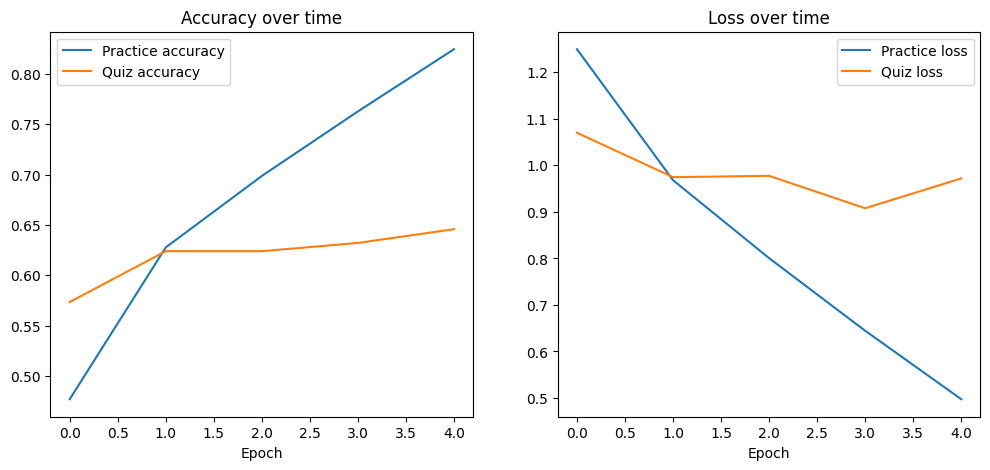

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Practice accuracy')
plt.plot(epochs_range, val_acc, label='Quiz accuracy')
plt.legend()
plt.title('Accuracy over time')
plt.xlabel('Epoch')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Practice loss')
plt.plot(epochs_range, val_loss, label='Quiz loss')
plt.legend()
plt.title('Loss over time')
plt.xlabel('Epoch')

plt.savefig('training_curves.png')
plt.show()

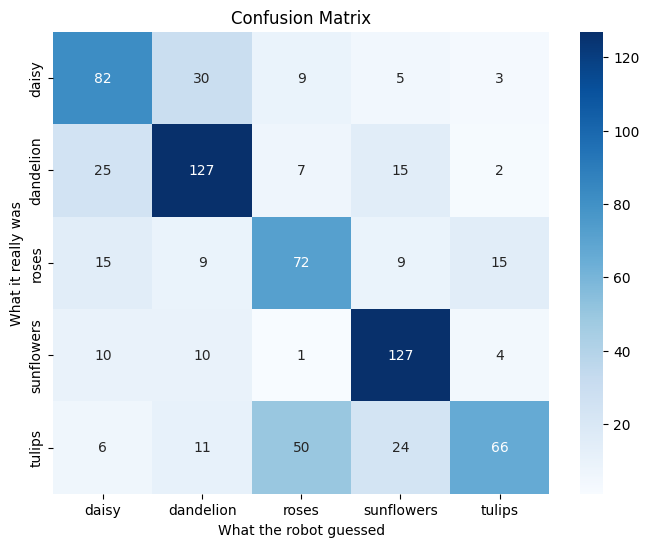

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('What the robot guessed')
plt.ylabel('What it really was')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

Task 5 – Performance Analysis

Results Summary:

Final training (practice) accuracy: 82.4%
Final validation (quiz) accuracy: 64.6%
The model correctly classifies flowers roughly 65% of the time on unseen images — well above random guessing (20% for 5 classes).

Training vs. Validation Curves:
The accuracy graph shows practice accuracy climbing steadily to 82%, while quiz accuracy plateaus around 62–65% after just the second epoch. The loss graph confirms this: practice loss keeps dropping smoothly, but quiz loss flattens and even ticks upward slightly by the final epoch. This is a clear sign of overfitting — the model is starting to memorize specific training images rather than learning general, reusable features of each flower type.

Confusion Matrix Findings:
The model performs strongest on dandelions (127 correct) and sunflowers (127 correct), likely because their distinctive colors and shapes (bright yellow centers, unique textures) make them easy to distinguish from other classes. It performs weakest on tulips, which are frequently misclassified as roses (50 out of 202 tulip images) — likely because both flowers share similar rounded petal shapes and overlapping color palettes (pink/red tones) when photographed up close.

Suggested Improvements:

Use transfer learning (e.g., a pretrained MobileNetV2 or ResNet model) instead of training a small CNN from scratch — this typically boosts accuracy significantly on small datasets like this one (~3,670 images).
Add data augmentation (random flips, rotations, zooms) to artificially create more training variety and reduce overfitting.
Add Dropout layers to randomly "turn off" some neurons during training, which forces the model to learn more general patterns instead of memorizing.
Train for more epochs with EarlyStopping, so training stops automatically at the best point instead of continuing to overfit.
Collect more training images, especially more varied photos of tulips and roses, to help the model tell them apart more reliably.